In [1]:
from pathlib import Path
import os
from matplotlib import pyplot as plt

IMG_SIZE = 65
PAD = 0
repo_root = Path("/home/karella/Projects/rotation-invariant-neural-networks/hippy2d")
os.chdir(repo_root)
print(Path.cwd())

/home/karella/Projects/rotation-invariant-neural-networks/hippy2d


In [1]:
# Function
import torch 
from typing import Optional
def make_ngon_structure(n, radius=1.0, angle=0.0,  device=None):
    """
    Regular n-particle structure centered at origin.

    Points:
        z_k = radius * exp(i * (angle + 2*pi*k/n))
    """
    k = torch.arange(n, device=device, dtype=torch.float32)
    angles = angle + 2 * torch.pi * k / n
    z = radius * torch.exp(1j * angles)
    # Convert to cartesian coordinates
    z = torch.stack([z.real, z.imag], dim=-1)
    return z
    
def _compute_complex_moments_2d(
    points: torch.Tensor,
    max_frequency: int,
    *,
    pq: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    """
    Compute sparse 2D complex moments from points with shape [..., N, 2].

    Each moment is
        mu_{p,q} = sum_n z_n^p conj(z_n)^q,
    where z_n = x_n + i y_n.
    """
    if points.ndim < 2:
        raise ValueError(f"Expected points with shape [..., N, 2], got {tuple(points.shape)}")
    if points.shape[-1] != 2:
        raise ValueError(f"Expected last dimension to be 2, got {points.shape[-1]}")
    if not torch.is_floating_point(points):
        raise TypeError("points must have a real floating-point dtype")

    if pq is None:
        pq = _complex_moment_pq(max_frequency, device=points.device)
    else:
        if pq.ndim != 2 or pq.shape[-1] != 2:
            raise ValueError(f"Expected orders with shape [M, 2], got {tuple(pq.shape)}")
        pq = pq.to(device=points.device, dtype=torch.long)

    z = torch.complex(points[..., 0], points[..., 1])
    z = z.unsqueeze(-1)

    p = pq[:, 0].to(dtype=z.real.dtype)
    q = pq[:, 1].to(dtype=z.real.dtype)

    moments = (z.pow(p) * z.conj().pow(q)).sum(dim=-2)
    return moments

def _complex_moment_pq(max_frequency: int, *, device: Optional[torch.device] = None) -> torch.Tensor:
    """Return all (p, q) with p >= q >= 0 and p + q <= max_frequency."""
    if max_frequency < 0:
        raise ValueError("max_frequency must be non-negative")

    orders = [
        (p, q)
        for total_degree in range(max_frequency + 1)
        for q in range(total_degree // 2 + 1)
        for p in [total_degree - q]
    ]
    return torch.tensor(orders, dtype=torch.long, device=device)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns


def plot_moment_diagnostics(
    angles,
    mag,
    phase,
    orders,
    mask_threshold=1e-1,
    filter_trivials=False,
    palette_name="husl",
    figsize=(20, 5.5),
    title="Moments of rotating 4-fold structure with fixed 3-fold structures",
    show=True,
):
    sns.set_theme(style="whitegrid", context="talk")

    n = mag.shape[-1]
    angles_np = np.asarray(angles)
    mag_np = mag.detach().cpu().numpy()
    phase_np = phase.detach().cpu().numpy()

    palette = sns.color_palette(palette_name, n)
    linestyles = ["-", "--", "-.", ":"]

    # Draw larger-average curves first so smaller ones stay visible on top
    plot_order = np.argsort(mag_np.mean(axis=0))[::-1]

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    for rank, idx in enumerate(plot_order):
        if filter_trivials and orders[idx] == 0:
            continue

        color = palette[idx]
        ls = linestyles[idx % len(linestyles)]
        label = f"Moment {orders[idx]}"

        line_kws = dict(
            color=color,
            linestyle=ls,
            linewidth=2.2,
            alpha=0.75,
            zorder=n - rank,
            path_effects=[
                pe.Stroke(linewidth=3.6, foreground="white", alpha=0.9),
                pe.Normal(),
            ],
        )

        # 1) Raw magnitudes
        axes[0].plot(angles_np, mag_np[:, idx], label=label, **line_kws)

        # 2) Phase, masked by threshold
        mag_mask = mag_np[:, idx] > mask_threshold
        phase_curve = np.cos(phase_np[:, idx]) * mag_mask
        axes[1].plot(angles_np, phase_curve, **line_kws)

        # 3) Magnitudes close to threshold region
        axes[2].plot(
            angles_np,
            mag_np[:, idx],
            color=color,
            linestyle=ls,
            linewidth=1.8,
            alpha=0.9,
            zorder=n - rank,
            path_effects=[
                pe.Stroke(linewidth=3.0, foreground="white", alpha=0.85),
                pe.Normal(),
            ],
        )

    axes[0].legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        ncol=1,
        fontsize=10,
    )
    axes[0].axhline(mask_threshold, color="black", linestyle=":", linewidth=1.5, alpha=0.8)
    axes[2].axhline(mask_threshold, color="black", linestyle=":", linewidth=1.5, alpha=0.8)

    axes[0].set_title("Moment magnitudes")
    axes[1].set_title("Phase cosine with hard mask")
    axes[2].set_title(f"Magnitudes near threshold ({mask_threshold:.2f})")

    for ax in axes:
        ax.set_xlabel("4-Fold Angle")
        for spine in ax.spines.values():
            spine.set_alpha(0.25)

    axes[0].set_ylabel("Magnitude")
    axes[1].set_ylabel("Cosine / masked")
    axes[2].set_ylabel("Magnitude")

    # Zoom the third panel so the threshold region is readable
    axes[2].set_ylim(0, mask_threshold)

    fig.suptitle(title)

    if show:
        plt.show()

    return fig, axes


Number of positive examples: 188
Number of negative examples: 172


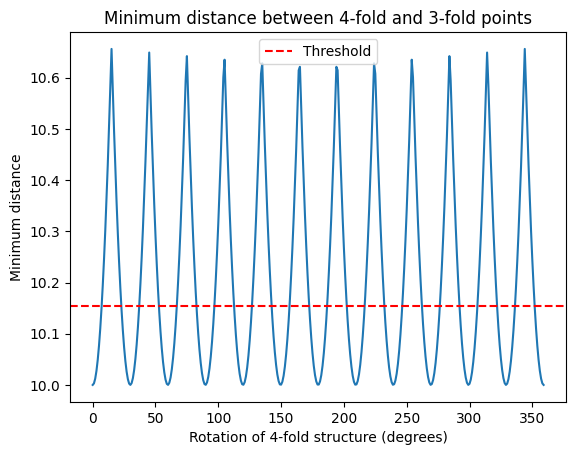

In [3]:
# Generate the dataset
# Create an adversial flexible example 
# * different distance between points 4-fold and 3-fold 
# * and maybe 1-fold, 4-fold and 3-fold 
# Single big convolution with circles as points 
#  
# Create four groups with random rotations. 
# Check what the instance norm one do to orders 
# Can we do an order and phase norm?? 
configurations = []
labels = []
mag = []
phase = []
radius_3fold = 10
radius_4fold = 20
threshold = 10.155

fold3 = make_ngon_structure(3, radius=radius_3fold, angle=0)  
min_dists = []
max_freq = 4
pq = _complex_moment_pq(max_freq)
angles = torch.linspace(0, 2 * torch.pi, steps=360)

for angle in angles:
    fold4 = make_ngon_structure(4, radius=radius_4fold, angle=angle)
    # Calculate pairwise distances between points in fold4 and fold3
    dists = torch.cdist(fold4, fold3)
    min_dist = dists.min()
    if min_dist < threshold:
        labels.append(False)
    else:        
        labels.append(True)
    min_dists.append(min_dist)
    configurations.append(torch.cat([fold4, fold3], dim=0))
    moments = _compute_complex_moments_2d(configurations[-1].unsqueeze(0), max_freq, pq=pq)
    mag.append(moments.abs())
    phase.append(moments.angle())


# Count labels
mag = torch.stack(mag, dim=0)[:, 0]
phase = torch.stack(phase, dim=0)[:, 0]
labels = torch.tensor(labels)
print(f"Number of positive examples: {labels.sum().item()}")
print(f"Number of negative examples: {(~labels).sum().item()}")
configurations = torch.stack(configurations, dim=0)
plt.plot(min_dists)
plt.title("Minimum distance between 4-fold and 3-fold points")
plt.xlabel("Rotation of 4-fold structure (degrees)")
plt.ylabel("Minimum distance")
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.legend()
plt.show()



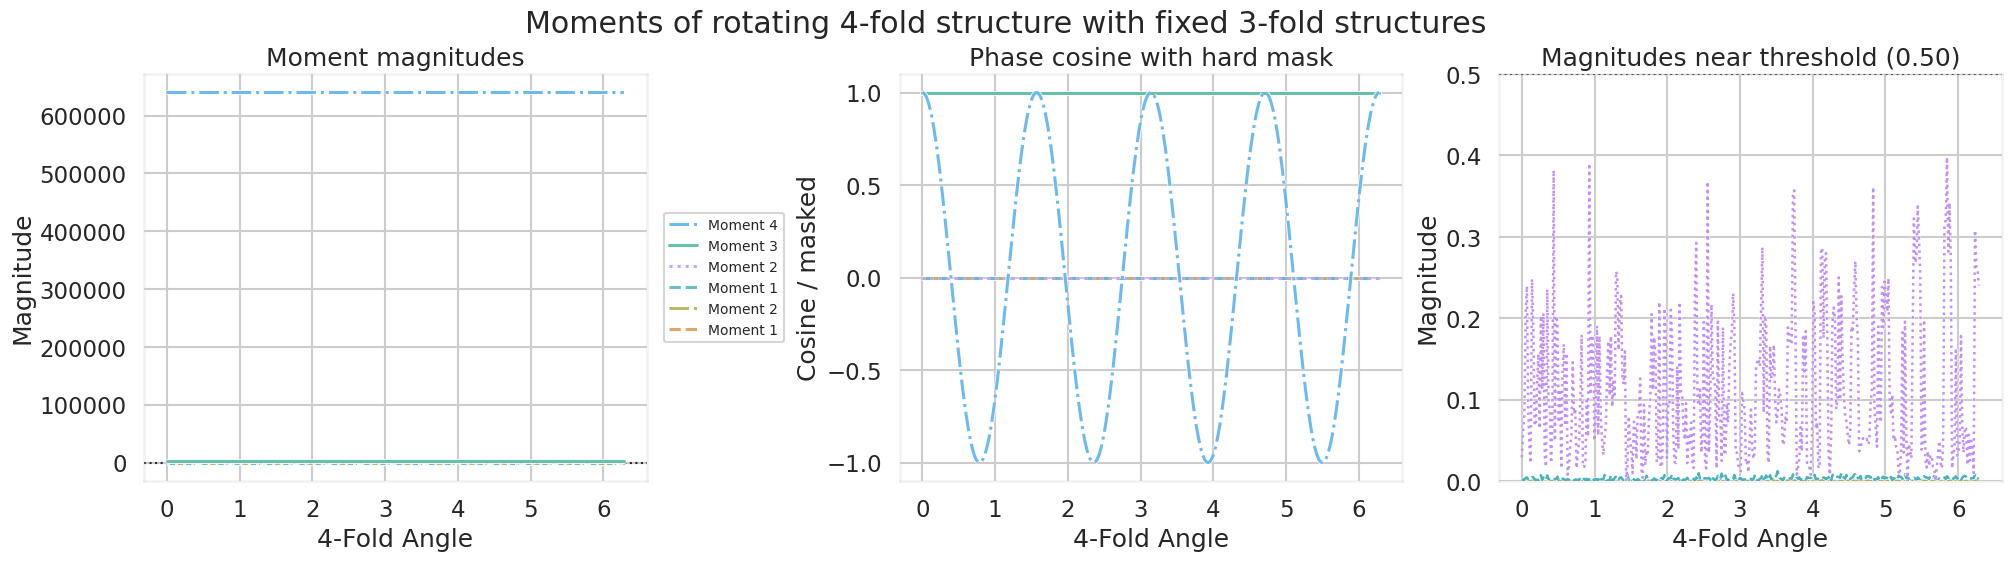

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

orders = [p - q for p, q in pq]

fig, axes = plot_moment_diagnostics(angles, mag, phase, orders, mask_threshold=0.5, filter_trivials=True)



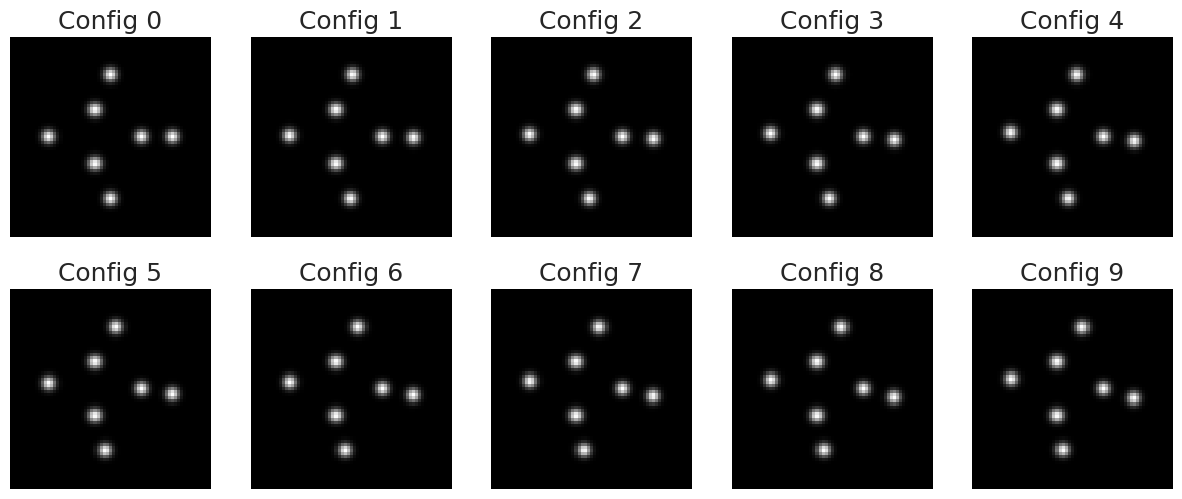

In [5]:
from hippy2d.utils import rasterize_point_configurations

rasterized = rasterize_point_configurations(configurations, IMG_SIZE, sigma=1.5)[:, None]
#Add padding
rasterized = torch.nn.functional.pad(rasterized, (PAD, PAD, PAD, PAD), mode="constant", value=0)


# Plot first few rasterized images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(rasterized[i, 0].cpu(), cmap="gray")
    ax.set_title(f"Config {i}")
    ax.axis("off")

In [6]:
from einops import rearrange
from hippy2d.escnn_prototype import flusser_basis_orders, MomentLayer, InvariantLayerMag, FixedFlusserMomentLayer, InvariantLayerMagReal, FlexibleInvariantLayer, InvariantsLayer, InvariantLayerMagNormReal

def get_non_trivials(moments, moment_layer):
    trivials_cnt = np.sum(np.array(moment_layer.orders) == 0)
    trivial_moments = moments[:, 0, :trivials_cnt, 0, 0]
    nontrivial_moments = rearrange(moments[:, 0, trivials_cnt:, 0, 0], 'b (o co) -> b o co', co=2).contiguous()
    nontrivial_moments = torch.complex(nontrivial_moments[:, :, 0], nontrivial_moments[:, :, 1])

    return trivial_moments, nontrivial_moments

MAX_ORDER = 4
orders = flusser_basis_orders(MAX_ORDER)
moment_layer = MomentLayer(max_order=MAX_ORDER,
                           orders=orders,
                           in_channels=1,
                           kernel_size=65,
                           padding='valid')


Non-trivial orders: [1 1 2 2 3 4]


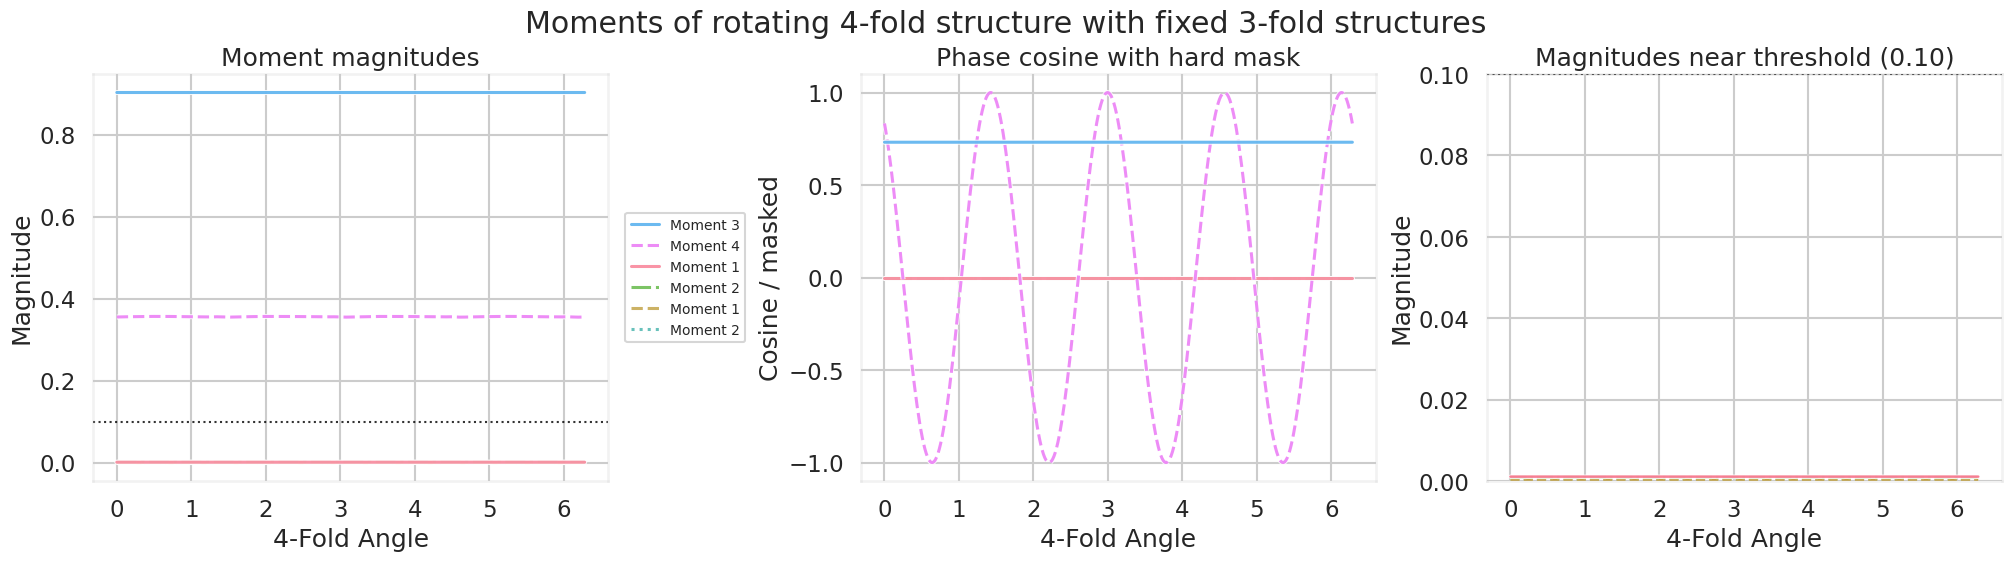

(<Figure size 2000x550 with 3 Axes>,
 array([<Axes: title={'center': 'Moment magnitudes'}, xlabel='4-Fold Angle', ylabel='Magnitude'>,
        <Axes: title={'center': 'Phase cosine with hard mask'}, xlabel='4-Fold Angle', ylabel='Cosine / masked'>,
        <Axes: title={'center': 'Magnitudes near threshold (0.10)'}, xlabel='4-Fold Angle', ylabel='Magnitude'>],
       dtype=object))

In [7]:

# Predict moments from rasterized images
with torch.no_grad():
    predicted_moments = moment_layer(rasterized)
    trivials, nontrivials = get_non_trivials(predicted_moments, moment_layer)
nontrivials = nontrivials.detach().cpu() 
# Only 1-orders 
non_trivial_orders = np.array(orders[len(orders) - nontrivials.shape[1]:])
print("Non-trivial orders:", non_trivial_orders)
mask = np.array([order > 0 for order in non_trivial_orders])
plot_moment_diagnostics(angles, nontrivials.abs()[:, mask], nontrivials.angle()[:, mask], non_trivial_orders[mask])

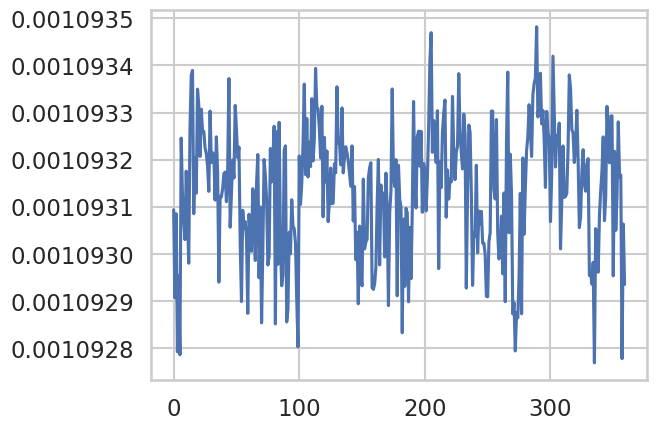

In [8]:
plt.plot(nontrivials[:, 0].abs()) 

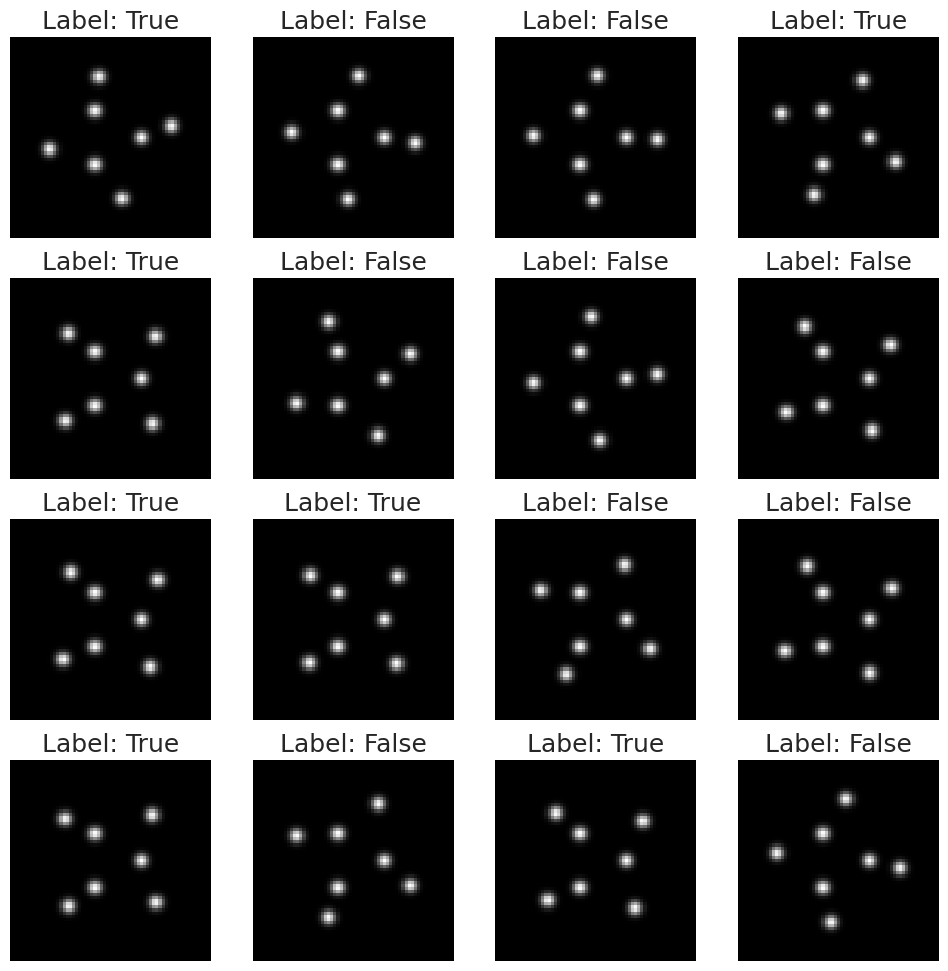

In [9]:
from torch.utils.data import TensorDataset, DataLoader

images = rasterized

dataset = TensorDataset(images, labels)

train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

# Plot the first batch of images and labels
batch_images, batch_labels = next(iter(train_loader))
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i in range(16):
    ax = axes[i // 4, i % 4]
    ax.imshow(batch_images[i, 0].cpu(), cmap="gray")
    ax.set_title(f"Label: {batch_labels[i].item()}")
    ax.axis("off")

In [11]:
import torch 
import numpy as np
from einops import rearrange
from hippy2d.escnn_prototype import flusser_basis_orders, MomentLayer, FixedFlusserMomentLayer, InvariantLayerMagReal, FlexibleInvariantLayer, InvariantsLayer, InvariantLayerMagNormReal, InvariantLayerMag

# Magnitude function 
import torch

def shifted_sigmoid_mag(r, tau=0.2, k=40.0):
    return torch.sigmoid(k * (r - tau))


# Just magnitudes 
#flusser_layer = InvariantLayerMag(orders=orders, in_channels=1, groups=1)
# Mag + Real normed
#flusser_layer = InvariantLayerMagNormReal(orders=orders, in_channels=1, groups=1)
flusser_layer = InvariantLayerMagReal(orders=orders, in_channels=1, groups=1, norm_mag_func=torch.nn.Identity())
#flusser_layer = FlexibleInvariantLayer(orders=orders, in_channels=1, groups=1, magnitude_func='none', max_b_exponent=MAX_ORDER)
#flusser_layer = InvariantsLayer(orders=orders, in_channels=1, groups=1)

spatial_dim = 1+PAD*2

network = torch.nn.Sequential(
    moment_layer,
    flusser_layer,
    torch.nn.AdaptiveAvgPool2d((1, 1)),
    torch.nn.Flatten(start_dim=-3, end_dim=-1),
    torch.nn.Linear(in_features=flusser_layer.out_channels,
                    out_features=64), 
    torch.nn.ReLU(), 
    torch.nn.Linear(in_features=64, out_features=2)
)
moments = network[:1](images)
invariants = network[:2](images)
trivials_cnt = np.sum(np.array(moment_layer.orders) == 0)

trivial_moments = moments[:, :, :trivials_cnt]
#nontrivial_moments = rearrange(moments[:, :, trivials_cnt:], 'b 1 (o co) 1 1 -> b o co', co=2)

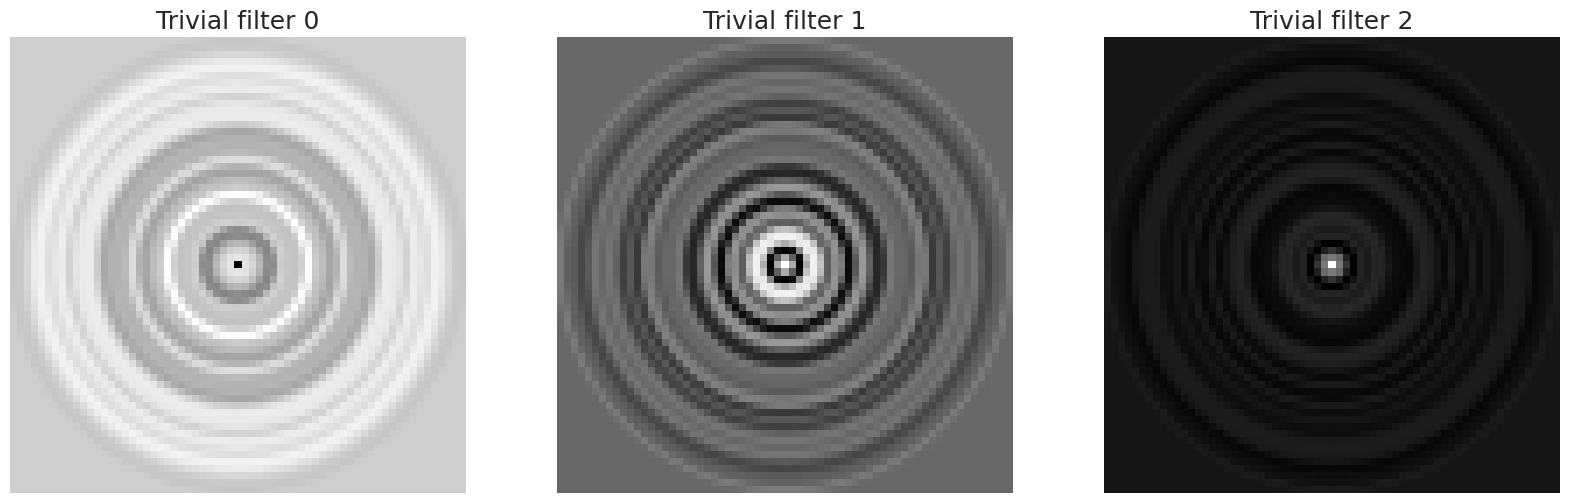

In [12]:
# Plot the filters
trivial_filters = moment_layer.expand_parameters()[:trivials_cnt, 0]
# plot the trivial filters
fig, axes = plt.subplots(1, trivials_cnt, figsize=(20, 12))
for i in range(trivials_cnt): 
    axes[i].imshow(trivial_filters[i].detach().numpy(), cmap='gray')
    axes[i].set_title(f"Trivial filter {i}")
    axes[i].axis('off')

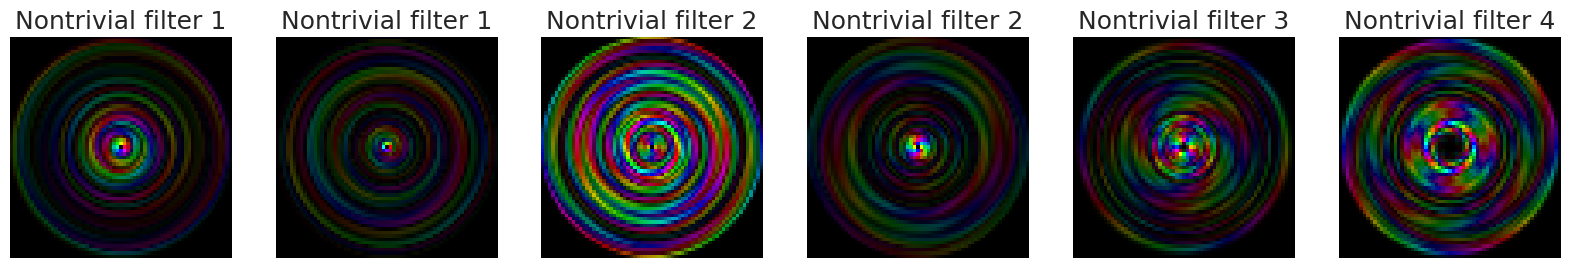

In [13]:
# Nontrivial filters
from hippy2d.utils import complex_to_rgb
nontrivial_filters = moment_layer.expand_parameters()[trivials_cnt:, 0]
nontrivial_filters = torch.view_as_complex(rearrange(nontrivial_filters, '(o co) h w -> o h w co', co=2).contiguous())

# plot all the nontrivial filters
fig, axes = plt.subplots(1, nontrivial_filters.shape[0], figsize=(20, 12))
for i in range(nontrivial_filters.shape[0]):
    filter_rgb = complex_to_rgb(nontrivial_filters[i].detach().numpy())
    axes[i].imshow(filter_rgb)
    axes[i].set_title(f"Nontrivial filter {orders[trivials_cnt + i]}")
    axes[i].axis('off')

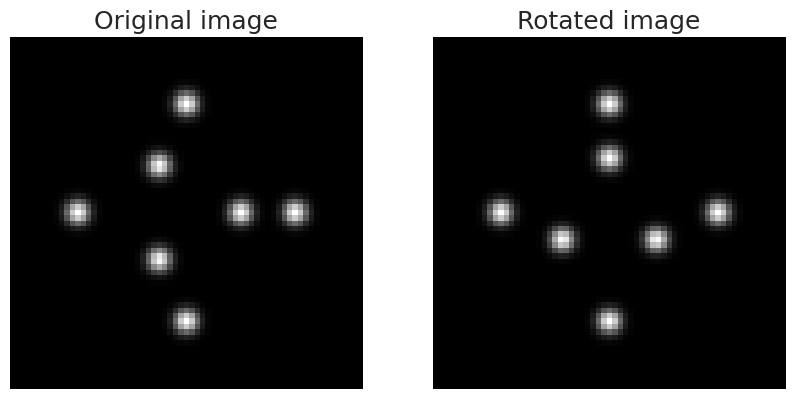

In [14]:
# Test the equivariance of the moments 
orders = moment_layer.orders
# sample img 
img = images[0:1]
# rotate by 90 degrees
img_rot = torch.rot90(img, k=1, dims=[-2, -1])

# Plot both images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img[0, 0].detach().numpy(), cmap='gray')
axes[0].set_title("Original image")
axes[0].axis('off')
axes[1].imshow(img_rot[0, 0].detach().numpy(), cmap='gray')
axes[1].set_title("Rotated image")
axes[1].axis('off')

# Calculate moments 
moments = moment_layer(img)
moments_rot = moment_layer(img_rot)
# Test trivials they are invariant


trivial_moments, nontrivial_moments = get_non_trivials(moments, moment_layer)
trivial_moments_rot, nontrivial_moments_rot = get_non_trivials(moments_rot, moment_layer)

torch.testing.assert_close(trivial_moments, trivial_moments_rot)
torch.testing.assert_close(nontrivial_moments.abs(), nontrivial_moments_rot.abs())

# Phase shift given by spins orders of the moments
phase_shift = torch.exp(1j * torch.tensor(np.pi / 2 * np.array(moment_layer.orders)[np.array(moment_layer.orders) != 0]))
nontrivial_moments_rot_phase = nontrivial_moments * phase_shift.to(torch.complex64)
torch.testing.assert_close(nontrivial_moments_rot, nontrivial_moments_rot_phase)

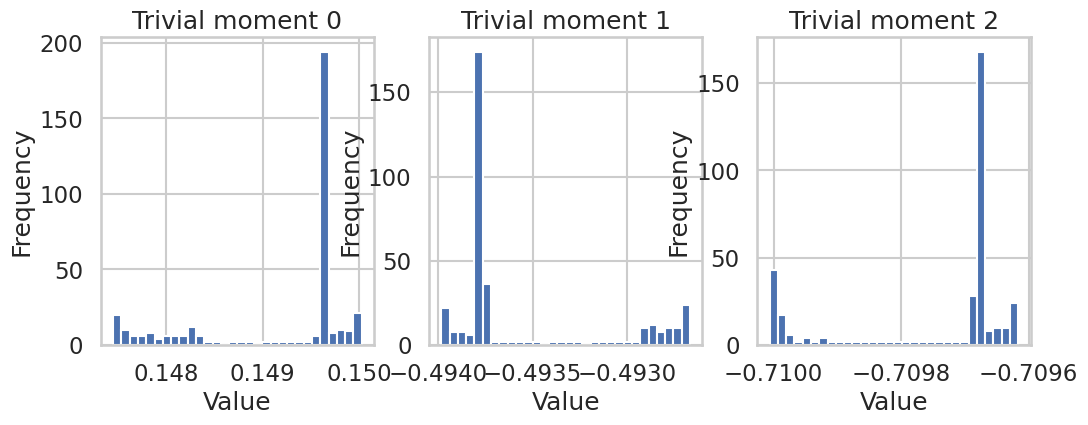

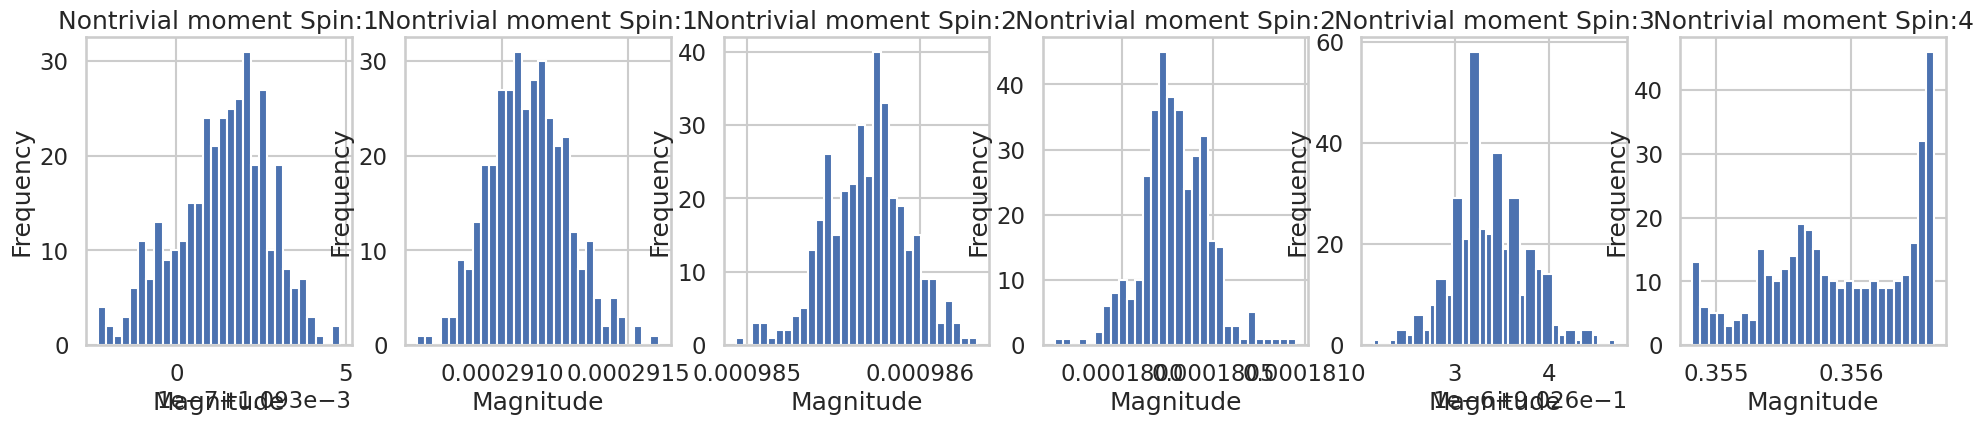

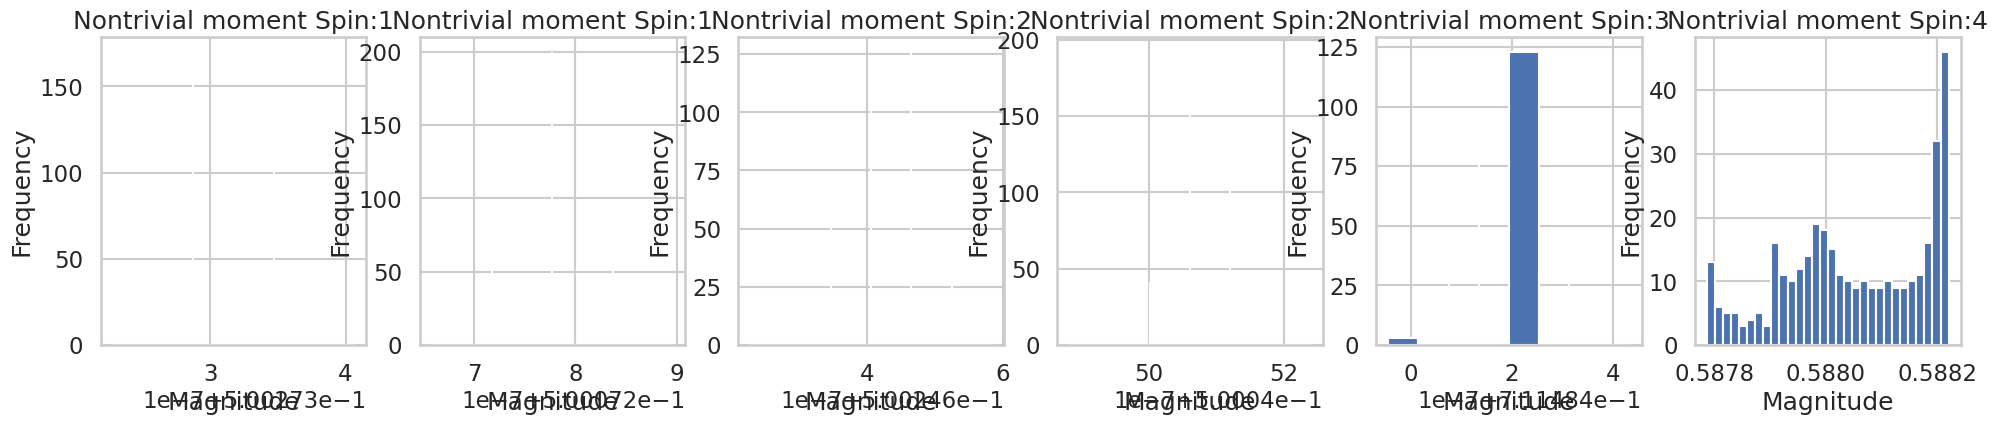

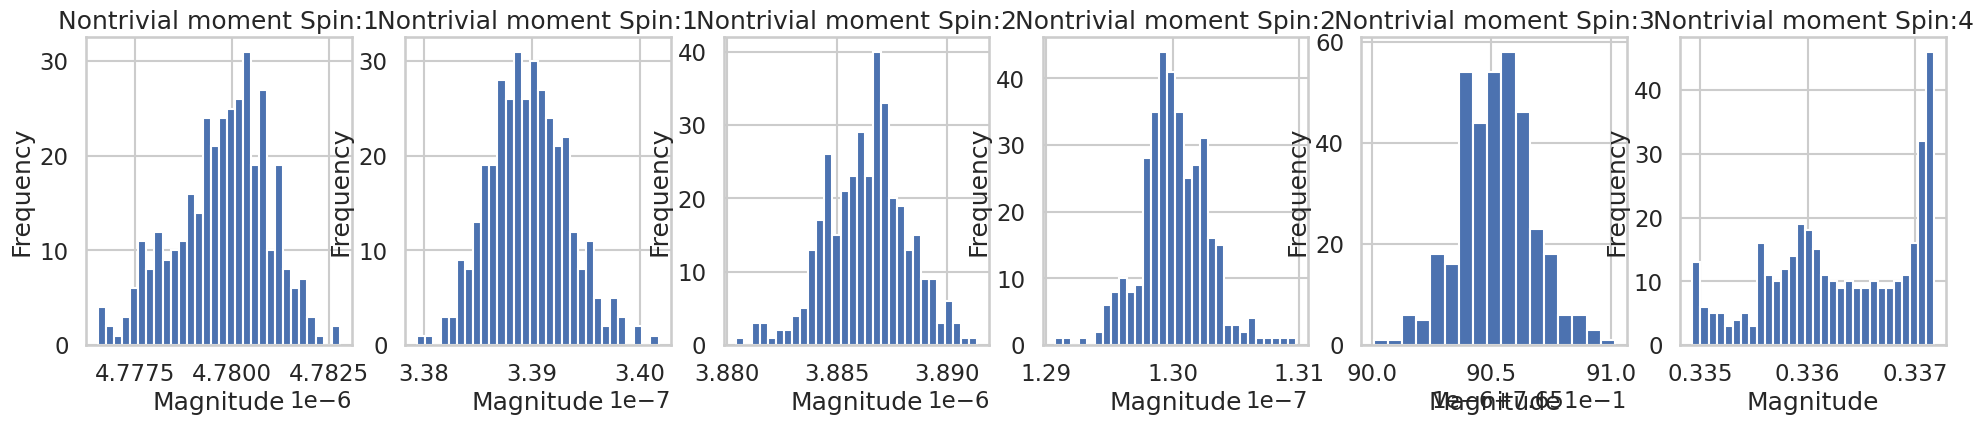

In [15]:
# Plot distribution of moments in the batch 
moments = moment_layer(images)
trivial_moments, nontrivial_moments = get_non_trivials(moments, moment_layer)

def phase_weight(mag, tau=0.5, power=2):
    r2 = mag**power
    return r2 / (r2 + tau**power)

x = torch.linspace(0, 1.5, 400)
y = phase_weight(x, tau=1, power=3)

fig, axes = plt.subplots(1, trivial_moments.shape[1], figsize=(12, 4))
for i in range(trivial_moments.shape[1]):
    axes[i].hist(trivial_moments[:, i].detach().numpy(), bins=30)
    axes[i].set_title(f"Trivial moment {i}")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
plt.show()

# same for magnitudes of nontrivial moments
fig, axes = plt.subplots(1, nontrivial_moments.shape[1], figsize=(4 * nontrivial_moments.shape[1], 4))
for i in range(nontrivial_moments.shape[1]):
    axes[i].hist(nontrivial_moments[:, i].abs().detach().numpy(), bins=30)
    axes[i].set_title(f"Nontrivial moment Spin:{orders[trivials_cnt + i]}")
    axes[i].set_xlabel("Magnitude")
    axes[i].set_ylabel("Frequency")
plt.show()

# same for magnitudes of nontrivial moments
fig, axes = plt.subplots(1, nontrivial_moments.shape[1], figsize=(4 * nontrivial_moments.shape[1], 4))
for i in range(nontrivial_moments.shape[1]):
    axes[i].hist(torch.sigmoid(nontrivial_moments[:, i].abs()).detach().numpy(), bins=30)
    axes[i].set_title(f"Nontrivial moment Spin:{orders[trivials_cnt + i]}")
    axes[i].set_xlabel("Magnitude")
    axes[i].set_ylabel("Frequency")
plt.show()

fig, axes = plt.subplots(1, nontrivial_moments.shape[1], figsize=(4 * nontrivial_moments.shape[1], 4))
for i in range(nontrivial_moments.shape[1]):
    axes[i].hist(phase_weight(nontrivial_moments[:, i].abs()).detach().numpy(), bins=30)
    axes[i].set_title(f"Nontrivial moment Spin:{orders[trivials_cnt + i]}")
    axes[i].set_xlabel("Magnitude")
    axes[i].set_ylabel("Frequency")
plt.show()

In [16]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = network.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(network.parameters(), lr=1e-3)

num_epochs = 200

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=20,
    gamma=0.5
)


for epoch in range(num_epochs):
    network.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()
        logits = network(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        batch_size = images.size(0)

        train_loss_sum += loss.item() * batch_size
        train_correct += (preds == labels).sum().item()
        train_total += batch_size


    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total
    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0
    #with torch.no_grad():
    #    for images, labels in val_loader:
    #        images = images.to(device)
    #        labels = labels.to(device).long()

    #        logits = network(images)
    #        loss = criterion(logits, labels)

    #        preds = logits.argmax(dim=1)
    #        batch_size = images.size(0)

    #        val_loss_sum += loss.item() * batch_size
    #        val_correct += (preds == labels).sum().item(Epoch 200/200 | lr=0.000002 | train_loss=0.1812 | train_acc=0.9889 )
    #        val_total += batch_size

    #val_loss = val_loss_sum / val_total
    #val_acc = val_correct / val_total


    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"lr={current_lr:.6f} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        #f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
)



Epoch 01/200 | lr=0.001000 | train_loss=0.7002 | train_acc=0.4389 | 
Epoch 02/200 | lr=0.001000 | train_loss=0.6928 | train_acc=0.5222 | 
Epoch 03/200 | lr=0.001000 | train_loss=0.6933 | train_acc=0.5222 | 
Epoch 04/200 | lr=0.001000 | train_loss=0.6929 | train_acc=0.5222 | 
Epoch 05/200 | lr=0.001000 | train_loss=0.6923 | train_acc=0.5222 | 
Epoch 06/200 | lr=0.001000 | train_loss=0.6930 | train_acc=0.5222 | 
Epoch 07/200 | lr=0.001000 | train_loss=0.6926 | train_acc=0.5222 | 
Epoch 08/200 | lr=0.001000 | train_loss=0.6941 | train_acc=0.5222 | 
Epoch 09/200 | lr=0.001000 | train_loss=0.6936 | train_acc=0.5222 | 
Epoch 10/200 | lr=0.001000 | train_loss=0.6924 | train_acc=0.5222 | 
Epoch 11/200 | lr=0.001000 | train_loss=0.6936 | train_acc=0.5222 | 
Epoch 12/200 | lr=0.001000 | train_loss=0.6925 | train_acc=0.5222 | 
Epoch 13/200 | lr=0.001000 | train_loss=0.6928 | train_acc=0.5222 | 
Epoch 14/200 | lr=0.001000 | train_loss=0.6926 | train_acc=0.5222 | 
Epoch 15/200 | lr=0.001000 | train

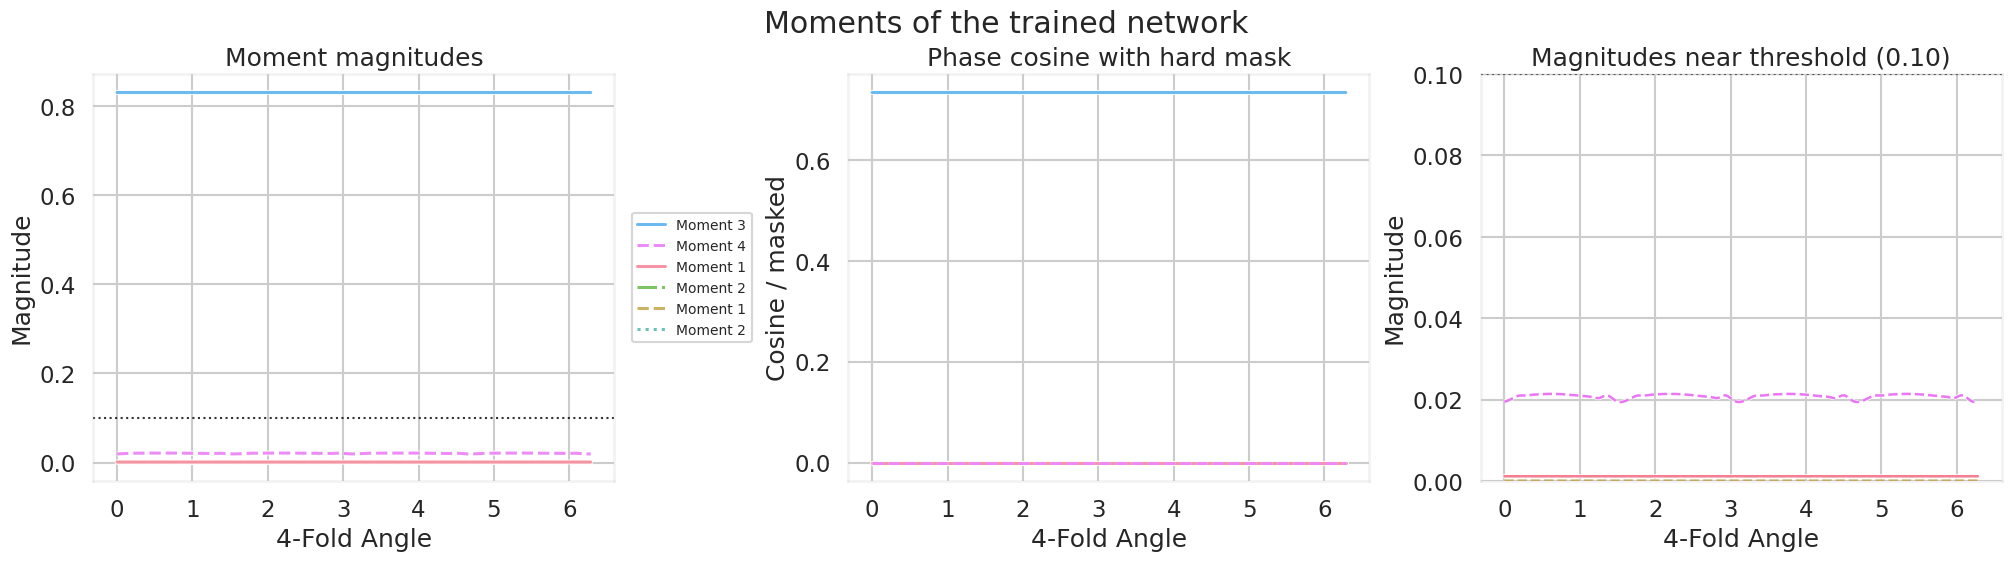

In [17]:
# Calculate moments for all images 
with torch.no_grad():
    predicted_moments = moment_layer(rasterized.to(device))
    predicted_moments = predicted_moments.detach().cpu()
    trivials, nontrivials = get_non_trivials(predicted_moments, moment_layer)
    plot_moment_diagnostics(angles, nontrivials.abs(), nontrivials.angle(), orders[len(orders) - nontrivials.shape[1]:], mask_threshold=0.1, filter_trivials=True, title="Moments of the trained network")

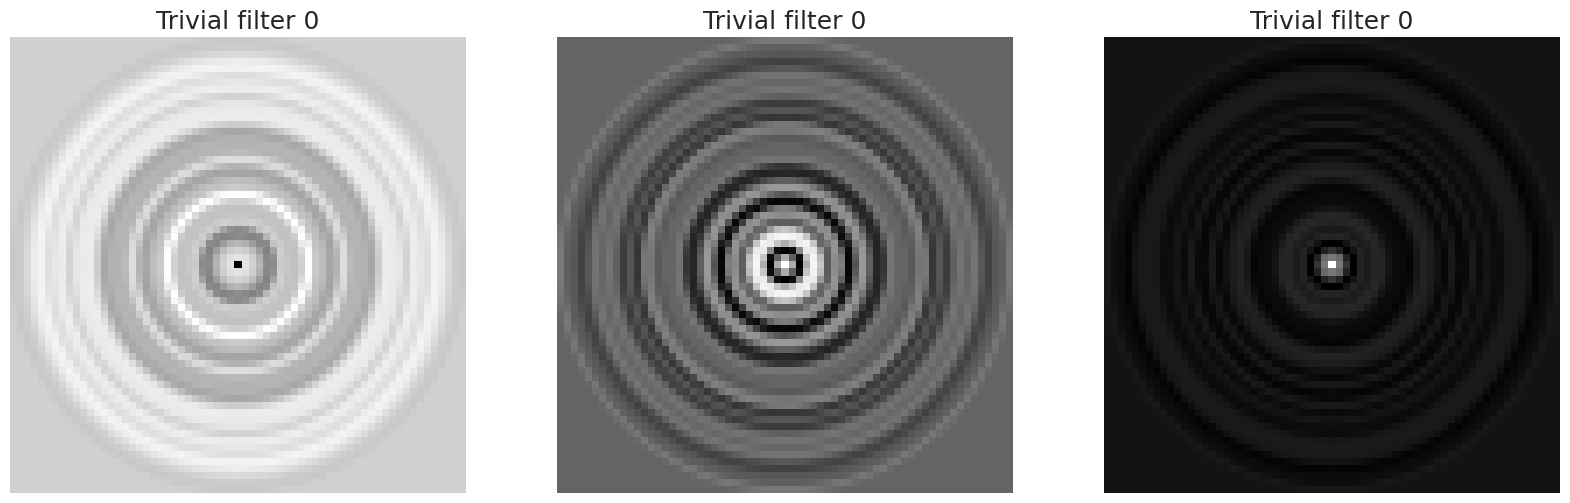

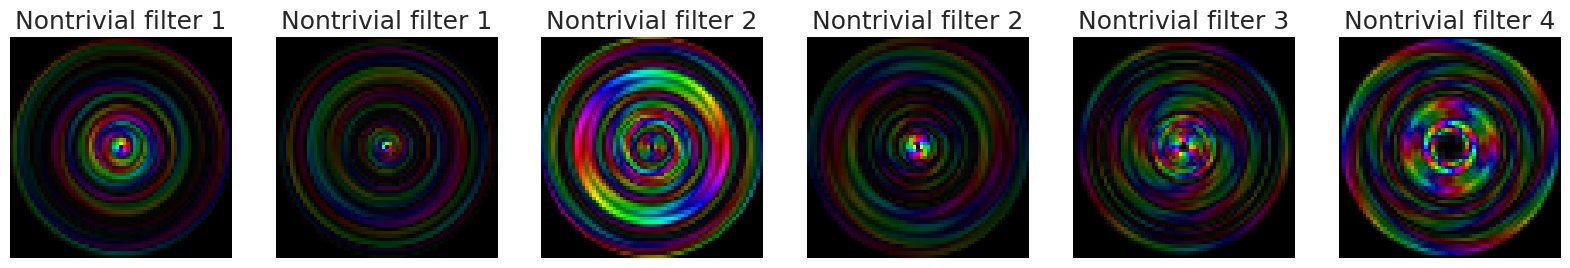

In [18]:
# plot the moment filters
with torch.no_grad():
    trivial_filters, nontrivial_filters = moment_layer.expand_parameters()[:trivials_cnt, 0], moment_layer.expand_parameters()[trivials_cnt:, 0]
    nontrivial_filters = torch.view_as_complex(rearrange(nontrivial_filters, '(o co) h w -> o h w co', co=2).contiguous())

    # plot all the trivial filters
    fig, axes = plt.subplots(1, trivial_filters.shape[0], figsize=(20, 12))
    for i in range(trivial_filters.shape[0]):
        filter_gray = trivial_filters[i].cpu().detach().numpy()
        axes[i].imshow(filter_gray, cmap='gray')
        axes[i].set_title(f"Trivial filter {orders[i]}")
        axes[i].axis('off')

    # plot all the nontrivial filters
    fig, axes = plt.subplots(1, nontrivial_filters.shape[0], figsize=(20, 12))
    for i in range(nontrivial_filters.shape[0]):
        filter_rgb = complex_to_rgb(nontrivial_filters[i].cpu().detach().numpy())
        axes[i].imshow(filter_rgb)
        axes[i].set_title(f"Nontrivial filter {orders[trivials_cnt + i]}")
        axes[i].axis('off')

In [ ]:
with torch.no_grad():
    # Test the equivariance of the moments 
    orders = moment_layer.orders
    # sample img 
    img = images[0:1]
    # rotate by 90 degrees
    img_rot = torch.rot90(img, k=1, dims=[-2, -1])

    # Plot both images
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img[0, 0].cpu().detach().numpy(), cmap='gray')
    axes[0].set_title("Original image")
    axes[0].axis('off')
    axes[1].imshow(img_rot[0, 0].cpu().detach().numpy(), cmap='gray')
    axes[1].set_title("Rotated image")
    axes[1].axis('off')

    # Calculate moments 
    moments = moment_layer(img).detach().cpu()
    moments_rot = moment_layer(img_rot).detach().cpu()
    # Test trivials they are invariant


    trivial_moments, nontrivial_moments = get_non_trivials(moments, moment_layer)
    trivial_moments_rot, nontrivial_moments_rot = get_non_trivials(moments_rot, moment_layer)

    torch.testing.assert_close(trivial_moments, trivial_moments_rot)
    torch.testing.assert_close(nontrivial_moments.abs(), nontrivial_moments_rot.abs())

    # Phase shift given by spins orders of the moments
    phase_shift = torch.exp(1j * torch.tensor(np.pi / 2 * np.array(moment_layer.orders)[np.array(moment_layer.orders) != 0]))
    nontrivial_moments_rot_phase = nontrivial_moments * phase_shift.to(torch.complex64)
    torch.testing.assert_close(nontrivial_moments_rot, nontrivial_moments_rot_phase)

In [ ]:
# get the invariants 
with torch.no_grad():
    inv_layers = network[:2]
    invariants = inv_layers(rasterized.to(device)).detach().cpu()
     


In [ ]:
invariants.shape
plt.plot(invariants[:, -1, 0, 0]) 

In [ ]:
inv_layers[1].tril_rows

In [ ]:
inv_layers[1].tril_cols

In [ ]:
inv_layers[1].nontrivial_orders

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def phase_weight(r, tau=0.3, p=8):
    return r**p / (r**p + tau**p)

def shifted_sigmoid_mag(r, tau=0.5, k=40.0):
    return torch.sigmoid(k * (r - tau))

sns.set_theme(style="whitegrid", context="talk")

r = torch.linspace(0.0, 1.0, 800)
r_np = r.numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
fig.patch.set_facecolor("#f7f4ed")

palette_tau = sns.color_palette("crest", 3)
palette_shape = sns.color_palette("flare", 3)

def style_ax(ax, title):
    ax.set_title(title, fontsize=13, weight="bold")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("radius r")
    ax.set_ylabel("gate value")
    ax.grid(True, alpha=0.18)
    for spine in ax.spines.values():
        spine.set_alpha(0.25)

# phase_weight: vary tau
ax = axes[0, 0]
for color, tau in zip(palette_tau, [0.20, 0.35, 0.50]):
    y = phase_weight(r, tau=tau, p=8).numpy()
    ax.plot(r_np, y, lw=3, color=color, label=fr"$\tau={tau:.2f},\, p=8$")
    ax.axvline(tau, color=color, ls="--", lw=1.2, alpha=0.4)
style_ax(ax, "Phase Weight: varying threshold")
ax.legend(frameon=True, fontsize=11)

# phase_weight: vary p
ax = axes[1, 0]
for color, p in zip(palette_shape, [2, 8, 16]):
    y = phase_weight(r, tau=0.35, p=p).numpy()
    ax.plot(r_np, y, lw=3, color=color, label=fr"$\tau=0.35,\, p={p}$")
ax.axvline(0.35, color="#444444", ls="--", lw=1.2, alpha=0.35)
style_ax(ax, "Phase Weight: varying sharpness")
ax.legend(frameon=True, fontsize=11)

# shifted_sigmoid_mag: vary tau
ax = axes[0, 1]
for color, tau in zip(palette_tau, [0.20, 0.35, 0.50]):
    y = shifted_sigmoid_mag(r, tau=tau, k=40.0).numpy()
    ax.plot(r_np, y, lw=3, color=color, label=fr"$\tau={tau:.2f},\, k=40$")
    ax.axvline(tau, color=color, ls="--", lw=1.2, alpha=0.4)
style_ax(ax, "Shifted Sigmoid: varying threshold")
ax.legend(frameon=True, fontsize=11)

# shifted_sigmoid_mag: vary k
ax = axes[1, 1]
for color, k in zip(palette_shape, [10.0, 25.0, 60.0]):
    y = shifted_sigmoid_mag(r, tau=0.35, k=k).numpy()
    ax.plot(r_np, y, lw=3, color=color, label=fr"$\tau=0.35,\, k={k:.0f}$")
ax.axvline(0.35, color="#444444", ls="--", lw=1.2, alpha=0.35)
style_ax(ax, "Shifted Sigmoid: varying sharpness")
ax.legend(frameon=True, fontsize=11)

fig.suptitle("Radial gating functions across parameter choices", fontsize=20, weight="bold", y=0.98)
fig.text(0.5, 0.01, "Dashed lines mark the threshold parameter tau", ha="center", fontsize=11, color="#4a4a4a")
plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()

